## Загрузка данных

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import polars as pl
from typing import List, Dict
from google.colab import drive
import lightgbm as lgb
drive.mount('/content/drive')

pd.options.display.float_format = '{:.4f}'.format

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
SUBSAMPLE = 'up0.001_ip0.001' #"ur0.01_ir0.01"
DRIVE_PATH = "/content/drive/MyDrive/echosphere/"
train_files = [f"subsamples/{SUBSAMPLE}/train/week_{i:02}.parquet" for i in range(25)]
meta_files  = [
    f"metadata/users_metadata.parquet",
    f"metadata/items_metadata.parquet",
    f"metadata/item_embeddings.npz",
]

In [ ]:
TRAIN_PATH = Path(f"{DRIVE_PATH}subsamples/{SUBSAMPLE}/train")
files = sorted(TRAIN_PATH.glob("week_*.parquet"))
weeks = [int(f.stem.split("_")[1]) for f in files]
week_map = dict(zip(weeks, files))

In [ ]:
def load_weeks(files):
    dfs = []
    for i, f in enumerate(files):
        week = int(f.split("_")[2].split('.')[0])
        df = pd.read_parquet(f)
        df["week"] = week
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

In [ ]:
files = [str(week_map[w]) for w in range(0, 25)]
full_data = load_weeks(files)

In [ ]:
items_subset = pd.read_parquet('/content/drive/MyDrive/echosphere/metadata/items_metadata.parquet')
items_subset.head()

,item_id,author_id,duration,train_interactions_rank
0,88620250,558,11,19270549
1,218436133,558,14,19264036
2,436082061,558,14,19264046
3,344447950,558,15,19181835
4,62832841,558,17,19184376


In [ ]:
full_data = full_data.merge(items_subset, on='item_id')
full_data.head(2)

,user_id,item_id,place,platform,agent,timespent,like,dislike,share,bookmark,click_on_author,open_comments,week,author_id,duration,train_interactions_rank
0,141827770,160593626,1,1,1,56,False,False,False,False,False,False,0,250935,83,9508
1,468779351,327484273,1,0,0,1,False,False,False,False,False,False,0,1178975,12,344


## Разбиение данных

In [ ]:
train_week_end = 5
test_week_end = 6

In [ ]:
full_data = full_data[full_data['timespent'] > 30]
full_data.shape

(7618783, 16)

In [ ]:
#full_data = full_data[full_data['like'] == True]
#full_data.shape

In [ ]:
full_data.head(2)

,user_id,item_id,place,platform,agent,timespent,like,dislike,share,bookmark,click_on_author,open_comments,week,author_id,duration,train_interactions_rank
0,141827770,160593626,1,1,1,56,False,False,False,False,False,False,0,250935,83,9508
3,453833313,102672169,0,0,0,45,False,False,False,False,False,False,0,1040966,45,7126


In [ ]:
train = full_data[full_data['week'] <= train_week_end]
test = full_data[full_data['week'] == test_week_end]

In [ ]:
dynamics = full_data[full_data['week'] > test_week_end]

In [ ]:
dynamics = pl.DataFrame(dynamics)

## Обучение модели

In [ ]:
DEFAULT_USER = 0
DEFAULT_TOP_K = 10

In [ ]:
class Random:
    def __init__(self, is_uniform: bool = True, seed: int = 0):
        self.seed = seed
        self.is_uniform = is_uniform
        self.all_ids = None
        self.p = None

    def fit(self, data: pl.DataFrame, id_name: str = "product_id"):
        self.all_ids = data[id_name].unique().to_list()

        if self.is_uniform:
            self.p = [1 / len(self.all_ids)] * len(self.all_ids)
        else:
            freq = (
                data.group_by(id_name)
                .len()
                .sort(id_name)
            )
            freq = freq.with_columns((pl.col("len") / data.shape[0]).alias("p"))
            self.p = freq["p"].to_list()

    def predict(self, user_id: int = 0, top_k: int = 10):
        return np.random.choice(self.all_ids, size=top_k, replace=False, p=self.p)

In [ ]:
class TopPopular:
    def __init__(self):
        self.sort_data = None
        self.id_name = None

    def fit(self, data: pl.DataFrame, id_name: str = 'product_id'):
        self.sort_data = (
            data
            .group_by(id_name)
            .len()
            .sort('len', descending=True)
        )
        self.id_name = id_name

    def predict(self, user_id: int = DEFAULT_USER, top_k: int = DEFAULT_TOP_K) -> List[int]:
        return self.sort_data.limit(top_k)[self.id_name].to_list()

In [ ]:
class PersonalTopPopular:
    def __init__(self):
        self.sort_data = None
        self.id_name = None
        self.user_id = None

    def fit(self, data: pl.DataFrame, id_name: str = 'product_id', user_id: str = 'user_id'):
        self.sort_data = (
            data
            .group_by(user_id, id_name)
            .len()
            .sort('len', descending=True)
        )
        self.id_name = id_name
        self.user_id = user_id

    def predict(self, user_id: int = DEFAULT_USER, top_k: int = DEFAULT_TOP_K) -> List[int]:
        return (
            self.sort_data
            .filter(pl.col(self.user_id) == user_id)
            .limit(top_k)[self.id_name]
        ).to_list()

In [ ]:
class PersonalTopPopularV2:
    def __init__(self, top_popular: TopPopular, personal_top_popular: PersonalTopPopular):
        self.top_popular = top_popular
        self.personal_top_popular = personal_top_popular

    def fit(self, data: pl.DataFrame, id_name: str = 'product_id', user_id: str = 'user_id'):
        self.top_popular.fit(data, id_name)
        self.personal_top_popular.fit(data, id_name, user_id)

    def predict(self, user_id: int = DEFAULT_USER, top_k: int = DEFAULT_TOP_K) -> List[int]:
        recs = []
        pers_top = self.personal_top_popular.predict(user_id, top_k)
        if len(pers_top) < top_k:
            top = self.top_popular.predict(user_id, top_k - len(pers_top))
            recs = pers_top + top
        else:
            recs = pers_top
        return recs

In [ ]:
class AuthorPersonalTop:
    def __init__(self, author_col: str = "author_id"):
        self.author_col = author_col

        self.user_authors: Dict[int, List[int]] = {}
        self.author_top_items: Dict[int, List[int]] = {}
        self.user_seen: Dict[int, set] = {}

    def fit(
        self,
        data: pl.DataFrame,
        id_name: str = "item_id",
        user_id: str = "user_id",
    ):
        item_col = id_name
        user_col = user_id
        author_col = self.author_col

        # --- user history
        hist = (
            data.group_by(user_col)
            .agg(pl.col(item_col).unique())
            .to_dict(as_series=False)
        )
        self.user_seen = {
            u: set(v)
            for u, v in zip(hist[user_col], hist[item_col])
        }

        # --- user -> authors (по частоте)
        user_authors_df = (
            data.group_by([user_col, author_col])
            .agg(pl.count().alias("cnt"))
            .sort([user_col, "cnt"], descending=True)
        )

        self.user_authors = {}
        for u, a, _ in user_authors_df.iter_rows():
            self.user_authors.setdefault(u, []).append(a)

        # --- author -> top items
        author_items_df = (
            data.group_by([author_col, item_col])
            .agg(pl.count().alias("cnt"))
            .sort([author_col, "cnt"], descending=True)
        )

        self.author_top_items = {}
        for a, i, _ in author_items_df.iter_rows():
            self.author_top_items.setdefault(a, []).append(i)

    def predict(
        self,
        user_id: int = DEFAULT_USER,
        top_k: int = DEFAULT_TOP_K,
    ) -> List[int]:

        recs = []
        seen = self.user_seen.get(user_id, set())
        authors = self.user_authors.get(user_id, [])

        for author in authors:
            items = self.author_top_items.get(author, [])

            for item in items:
                if item not in seen and item not in recs:
                    recs.append(item)

                if len(recs) >= top_k:
                    return recs

        return recs

In [ ]:
def calc_pr_metrics(data, recs_column: str, top_k: int = DEFAULT_TOP_K):
    metrics = (
        data
        .select('user_id', 'ids', recs_column)
        .with_columns([
            pl.col('ids').list.set_intersection(pl.col(recs_column)).alias(f'relevant_in_{recs_column}')
        ])
        .with_columns([
            pl.col(f'relevant_in_{recs_column}').list.len().alias('len1'),
            pl.col(recs_column).list.len().alias('len2'),
            pl.col('ids').list.len().alias('len3')
        ])
        .with_columns([
            (pl.col('len1') / pl.col('len3')).alias('recall'),
            (pl.col('len1') / top_k).alias('precision'),
        ])
        .fill_nan(0)
        .select(
            pl.mean('recall').alias('recall'),
            pl.mean('precision').alias('precision')
        )
    )
    return metrics

In [ ]:
train = pl.DataFrame(train)
test = pl.DataFrame(test)

In [ ]:
tp = TopPopular()
tp.fit(train, id_name='item_id')

rn = Random(is_uniform=False)
rn.fit(train, id_name='item_id')

ptp = PersonalTopPopular()
ptp.fit(train, id_name='item_id')

ptp_v2 = PersonalTopPopularV2(top_popular=TopPopular(), personal_top_popular=PersonalTopPopular())
ptp_v2.fit(train, id_name='item_id')

author_top = AuthorPersonalTop()
author_top.fit(train)

/tmp/ipykernel_19946/2126455853.py:33: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("cnt"))
/tmp/ipykernel_19946/2126455853.py:44: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("cnt"))


In [ ]:
users = (
    test
    .group_by('user_id')
    .agg(
        pl.col("item_id").unique().alias("ids")
    )
)

In [ ]:
recommemd_users = (
    users
    .with_columns([
        pl.col('user_id').map_elements(
            lambda x: tp.predict(user_id=x, top_k=100),
            return_dtype=pl.List(pl.Int64)
        ).alias('tp_recs'),

        pl.col('user_id').map_elements(
            lambda x: rn.predict(user_id=x, top_k=100),
            return_dtype=pl.List(pl.Int64)
        ).alias('rn_recs'),

        pl.col('user_id').map_elements(
            lambda x: ptp.predict(user_id=x, top_k=100),
            return_dtype=pl.List(pl.Int64)
        ).alias('ptp_recs'),

        pl.col('user_id').map_elements(
            lambda x: ptp_v2.predict(user_id=x, top_k=100),
            return_dtype=pl.List(pl.Int64)
        ).alias('ptp_v2_recs'),

        pl.col('user_id').map_elements(
            lambda x: author_top.predict(user_id=x, top_k=100),
            return_dtype=pl.List(pl.Int64)
        ).alias('author_top_recs'),
    ])
)
recommemd_users

user_id,ids,tp_recs,rn_recs,ptp_recs,ptp_v2_recs,author_top_recs
u32,list[u32],list[i64],list[i64],list[i64],list[i64],list[i64]
333605859,"[450235518, 286166578, … 373636505]","[329362081, 300222940, … 147417673]","[418868193, 502206635, … 442724847]","[9014696, 382070452, … 547058729]","[134717909, 147777745, … 253596569]","[517656757, 154450927, … 198851832]"
261092499,"[401304752, 306697560, … 478473509]","[329362081, 300222940, … 147417673]","[411285218, 389069142, … 331256446]","[323577324, 475706346, … 588482062]","[221351257, 474986722, … 75074809]","[193312460, 216380230, … 601066497]"
396712200,"[23643542, 510056291, … 246651052]","[329362081, 300222940, … 147417673]","[65692777, 188200733, … 80045447]","[48380692, 93781641, … 448854551]","[237911953, 429232532, … 47159027]","[70099273, 529258907, … 461099684]"
501536943,"[163064586, 79710602, … 373637767]","[329362081, 300222940, … 147417673]","[469638264, 548889785, … 188200733]","[437605009, 114707982, … 349355598]","[479530361, 544766093, … 155228213]","[596182847, 382070452, … 524268165]"
502245450,"[324467695, 296065506, … 386204158]","[329362081, 300222940, … 147417673]","[241696962, 225903878, … 468441330]","[172853777, 93767284, … 431926308]","[333180975, 72729667, … 331256446]","[180636794, 289316479, … 529258907]"
…,…,…,…,…,…,…
476720279,"[247783268, 202712692, … 159540998]","[329362081, 300222940, … 147417673]","[370295329, 370163186, … 464226900]","[148996778, 574321325, … 192881450]","[502799579, 165107032, … 193312460]","[165010507, 4189069, … 567908177]"
247758243,"[324181580, 130015285, … 122602758]","[329362081, 300222940, … 147417673]","[374348876, 2732280, … 413997314]","[312757262, 185679944, … 501952067]","[566045017, 420903135, … 131074786]","[80928590, 325112901, … 106211315]"
292328383,"[299581882, 489863736, … 177134440]","[329362081, 300222940, … 147417673]","[326193846, 26160905, … 93767284]","[237038455, 72434405, … 568515175]","[450756036, 382809099, … 8008420]","[596182847, 382070452, … 496028372]"


In [ ]:
calc_pr_metrics(recommemd_users, 'rn_recs')

recall,precision
f64,f64
0.014191,0.032085


In [ ]:
calc_pr_metrics(recommemd_users, 'tp_recs')

recall,precision
f64,f64
0.025124,0.055547


In [ ]:
calc_pr_metrics(recommemd_users, 'author_top_recs')

recall,precision
f64,f64
0.024627,0.047814


## Формирование начального мнения

In [ ]:
recommender = tp #rn, author_top]

In [ ]:
actions = dynamics.sort(["week"])

In [ ]:
from tqdm import tqdm

user_days = test.select(["user_id", "week"]).unique().sort(["user_id", "week"])

rows = []

for user_id, week in tqdm(user_days.iter_rows(), total=user_days.height):

    recs = recommender.predict(
        user_id=user_id,
        top_k=100
    )

    if recs is None:
        recs = []

    for rank, item_id in enumerate(recs):
        rows.append({
            "user_id": user_id,
            "week": week,
            "item_id": item_id,
            "rank": rank
        })

exposure = pl.DataFrame(rows)

100%|██████████| 9880/9880 [00:01<00:00, 7896.11it/s]


In [ ]:
full = (
    exposure
    .join(
        test,
        on=["user_id", "week", "item_id"],
        how="left"
    )
)

In [ ]:
full = full.with_columns(
    pl.when(pl.col("timespent") >= 30)
    .then(1)
    .otherwise(0)
    .fill_null(0)
    .alias("reaction")
)

In [ ]:
user_state = (
    full
    .group_by("user_id")
    .agg([
        pl.col("reaction").sum().alias("watched"),
        pl.len().alias("exposures")
    ])
    .with_columns(
        (pl.col("watched") / pl.col("exposures"))
        .fill_null(0)
        .alias("x0")
    )
)

In [ ]:
user_state

user_id,watched,exposures,x0
i64,i32,u32,f64
481459072,1,100,0.01
320762714,1,100,0.01
152195721,0,100,0.0
306086577,0,100,0.0
193664004,2,100,0.02
…,…,…,…
185922393,0,100,0.0
194913311,1,100,0.01
81784755,0,100,0.0


## Расчёт динамики

In [ ]:
from tqdm import tqdm

user_days = actions.select(["user_id", "week"]).unique()

rows = []

for user_id, week in tqdm(user_days.iter_rows(), total=user_days.height):
    recs = recommender.predict(user_id=user_id, top_k=100)

    rows.append({
        "user_id": user_id,
        "week": week,
        "item_id": recs
    })

100%|██████████| 178652/178652 [00:04<00:00, 40291.62it/s]


In [ ]:
exposure = pl.DataFrame(rows)

In [ ]:
exposure = exposure.explode("item_id")

In [ ]:
full = exposure.join(
    actions,
    on=["user_id", "week", "item_id"],
    how="left"
)

In [ ]:
full = full.with_columns(
    pl.when(pl.col("timespent") >= 30)
    .then(1)
    .otherwise(0)
    .fill_null(0)
    .alias("reaction")
)

In [ ]:
daily = (
    full
    .group_by(["user_id", "week"])
    .agg([
        pl.col("reaction").sum().alias("likes"),
        pl.len().alias("exposures")
    ])
    .with_columns(
        (pl.col("likes") / pl.col("exposures"))
        .fill_null(0)
        .alias("r_t")
    )
    .sort(["user_id", "week"])
)

In [ ]:
alphas = np.arange(0.0, 1., 0.1)

In [ ]:
base_data = (
    daily
    .with_columns(pl.col("week").cast(pl.Utf8))
    .select(["user_id", "week", "r_t"])
    .to_numpy()
)
base_data

array([[20125, '7', 0.01],
       [20125, '8', 0.01],
       [20125, '9', 0.0],
       ...,
       [510091816, '22', 0.01],
       [510091816, '23', 0.0],
       [510091816, '24', 0.0]], dtype=object)

In [ ]:
micro_rows = []
macro_rows = []

In [ ]:
x0_map = dict(zip(user_state["user_id"], user_state["x0"]))

In [ ]:
from collections import defaultdict
from tqdm import tqdm
from scipy.stats import wasserstein_distance

In [ ]:
for alpha in alphas:
    state = defaultdict(lambda: 0.0)

    prev_state = {}

    for user_id, date, r_t in tqdm(
        base_data,
        desc=f"α={alpha:.1f}"
    ):
        prev = state[user_id]
        new = alpha * prev + (1 - alpha) * r_t
        state[user_id] = new

        # =========================
        # MICRO
        # =========================
        if user_id in prev_state:
            micro = abs(new - prev_state[user_id])
        else:
            micro = 0.0

        prev_state[user_id] = new

        micro_rows.append({
            "alpha": alpha,
            "date": date,
            "micro_shift": micro
        })

    # =========================
    # MACRO (Wasserstein)
    # =========================

    x_t = np.array(list(state.values()))
    x_0 = np.array([
        x0_map.get(u, 0.0) for u in state.keys()
    ])

    macro = wasserstein_distance(x_0, x_t)

    macro_rows.append({
        "alpha": alpha,
        "macro_shift": macro
    })

α=0.9: 100%|██████████| 178652/178652 [00:01<00:00, 131687.79it/s]


In [ ]:
micro_acc = defaultdict(list)

for r in micro_rows:
    key = (r["alpha"], r["date"])
    micro_acc[key].append(r["micro_shift"])

In [ ]:
alphas = list(np.arange(0, 1, 0.1))
dates = sorted(set(r["date"] for r in micro_rows))

In [ ]:
a_idx = {a:i for i,a in enumerate(alphas)}
t_idx = {t:i for i,t in enumerate(dates)}

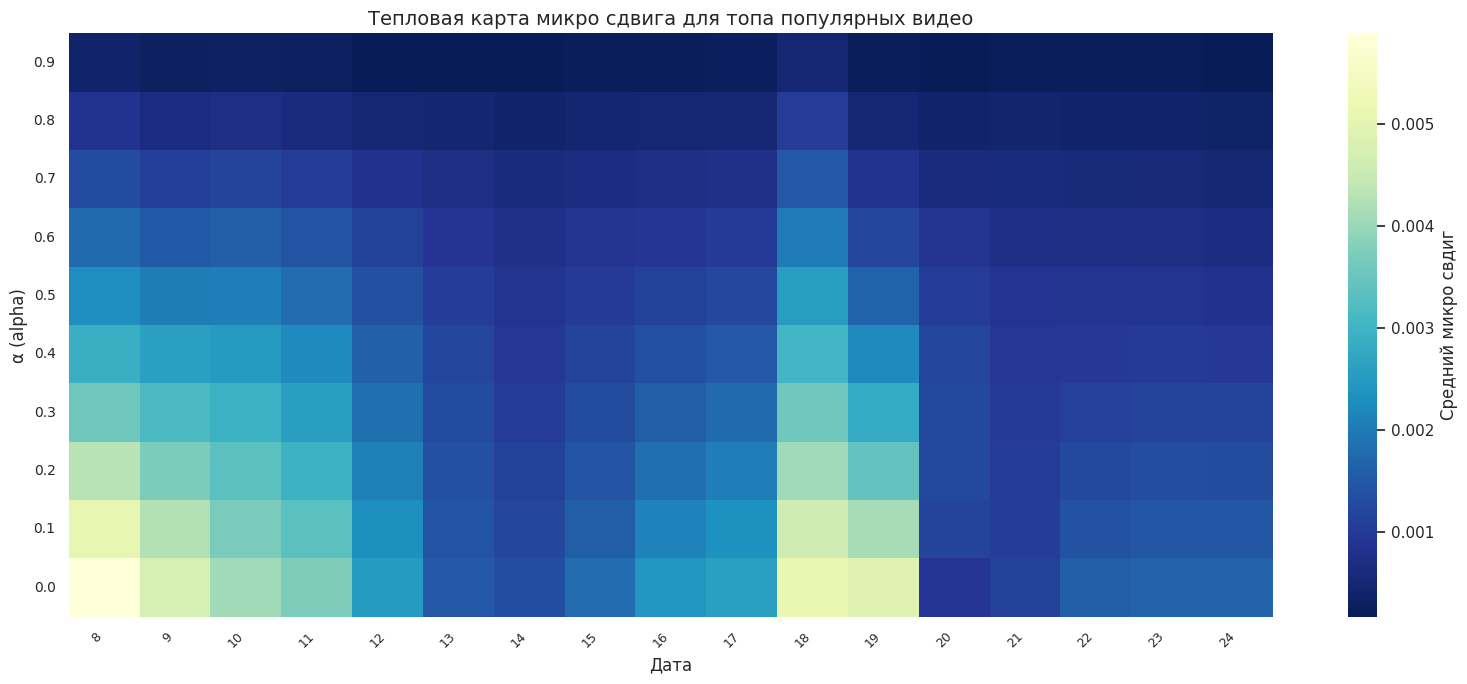

In [ ]:
## tp

sns.set_theme(style="whitegrid", palette="Purples")

df = pd.DataFrame(micro_rows)
df['alpha'] = df['alpha'].astype(float).round(1)
df['date'] = df['date'].astype(int)
df = df[df['date'] > 7]
df = df.sort_values('date')

# pivot
pivot_df = df.pivot_table(
    index='alpha',
    columns='date',
    values='micro_shift',
    aggfunc='mean'
)

plt.figure(figsize=(16, 7))

ax = sns.heatmap(
    pivot_df,
    cmap="YlGnBu_r",
    #vmin=0,        # ✔ нижняя граница
    #vmax=0.08,      # ✔ верхняя граница
    cbar_kws={'label': 'Средний микро свдиг'},
)

# инверсия оси Y
ax.invert_yaxis()

# читаемые даты
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=9
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)

plt.title('Тепловая карта микро сдвига для топа популярных видео', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('α (alpha)')

plt.tight_layout()
plt.show()

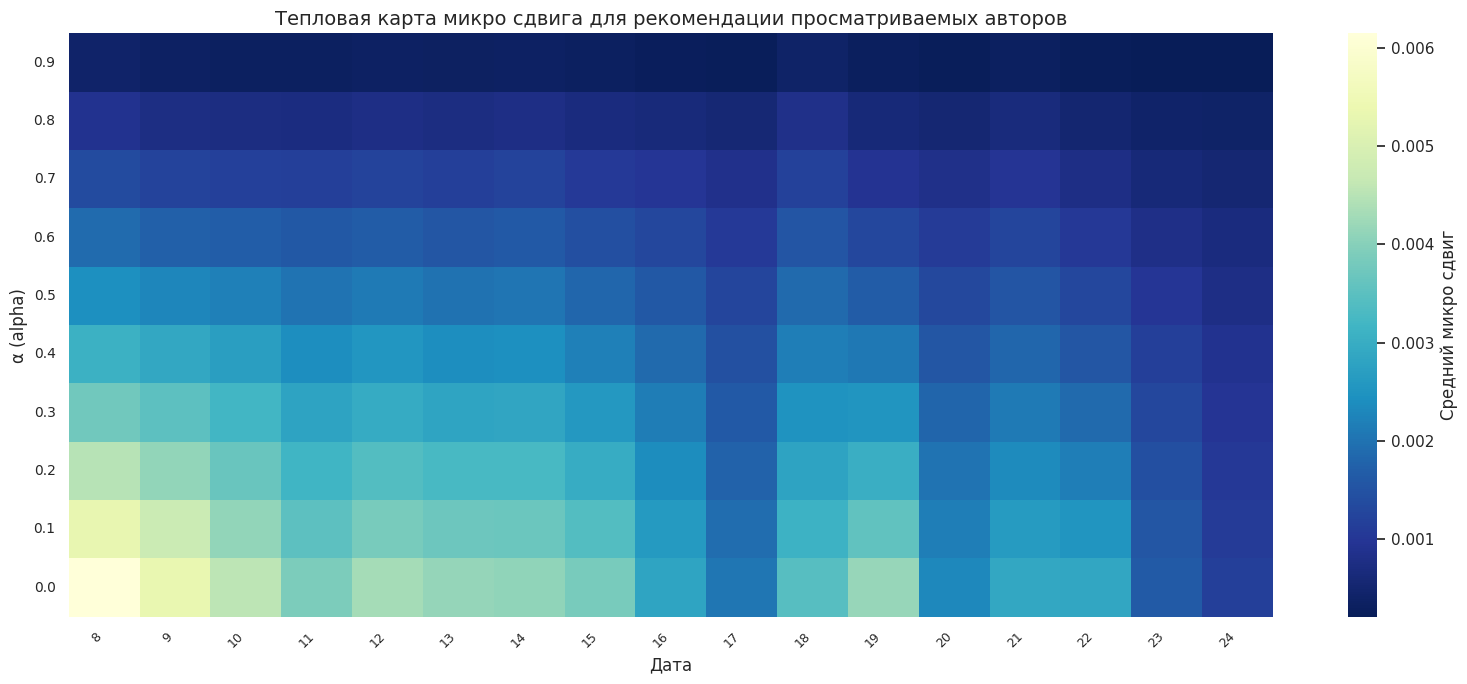

In [ ]:
## author_top

sns.set_theme(style="whitegrid", palette="Purples")

df = pd.DataFrame(micro_rows)
df['alpha'] = df['alpha'].astype(float).round(1)
df['date'] = df['date'].astype(int)
df = df[df['date'] > 7]
df = df.sort_values('date')

# pivot
pivot_df = df.pivot_table(
    index='alpha',
    columns='date',
    values='micro_shift',
    aggfunc='mean'
)

plt.figure(figsize=(16, 7))

ax = sns.heatmap(
    pivot_df,
    cmap="YlGnBu_r",
    #vmin=0,        # ✔ нижняя граница
    #vmax=0.08,      # ✔ верхняя граница
    cbar_kws={'label': 'Средний микро сдвиг'},
)

# инверсия оси Y
ax.invert_yaxis()

# читаемые даты
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=9
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)

plt.title('Тепловая карта микро сдвига для рекомендации просматриваемых авторов', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('α (alpha)')

plt.tight_layout()
plt.show()

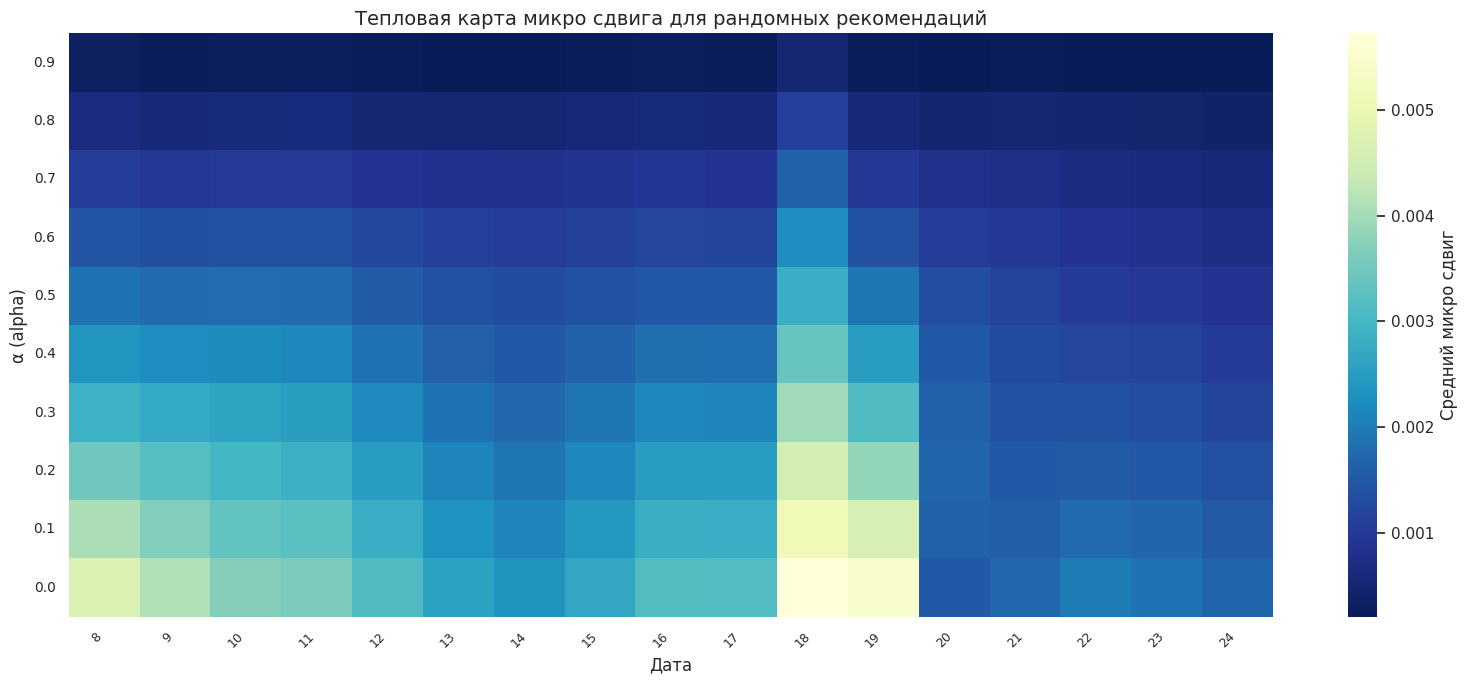

In [ ]:
## rn

sns.set_theme(style="whitegrid", palette="Purples")

df = pd.DataFrame(micro_rows)
df['alpha'] = df['alpha'].astype(float).round(1)
df['date'] = df['date'].astype(int)
df = df[df['date'] > 7]
df = df.sort_values('date')

# pivot
pivot_df = df.pivot_table(
    index='alpha',
    columns='date',
    values='micro_shift',
    aggfunc='mean'
)

plt.figure(figsize=(16, 7))

ax = sns.heatmap(
    pivot_df,
    cmap="YlGnBu_r",
    #vmin=0,        # ✔ нижняя граница
    #vmax=0.08,      # ✔ верхняя граница
    cbar_kws={'label': 'Средний микро сдвиг'},
)

# инверсия оси Y
ax.invert_yaxis()

# читаемые даты
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=9
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)

plt.title('Тепловая карта микро сдвига для рандомных рекомендаций', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('α (alpha)')

plt.tight_layout()
plt.show()